# Random Forest and Naive Bayes Classifiers

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply random forest classifiers to improve prediction accuracy
- Implement Naive Bayes for text classification tasks
- Evaluate classification models using confusion matrices, ROC curves
- Compare different classification algorithms

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 02 "Bayesian Networks" — Naive Bayes is the simplest such network, put to work as a classifier.

**Used later in:** Course 07 (AIAT 121) — Unit 3, where Naive Bayes is the first classifier applied to real text features.

---

This notebook covers practical activities from **Course 04, Unit 3**:
- Applying random forest classifiers to improve prediction accuracy
- Implementing Naive Bayes for text classification tasks like spam detection
- Evaluating classification models using confusion matrices, ROC curves


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../datasets/raw/creditcard_fraud.csv` — 284,807 real card transactions, 492 of them fraudulent
- `../../datasets/raw/montgomery_911_calls.csv` — real emergency-dispatch text, used for the Naive Bayes example

**Outputs:** What you'll see when you run the cells

- A Random Forest fraud detector with its classification report, confusion matrix and ROC curve
- A Naive Bayes text classifier that routes real dispatch descriptions to EMS / Fire / Traffic

---

In [1]:
# CELL: Import the two model families compared in this lesson.
# WHY: Random Forest (an ensemble of trees) and Naive Bayes (a probabilistic
# model) represent opposite philosophies - flexible vs. simple-but-fast.
# CountVectorizer turns raw text into word counts for the spam example.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Part 1: Random Forest Classification — Real Credit-Card Fraud

The dataset is the well-known Kaggle credit-card fraud file: 284,807 transactions made by
European cardholders over two days in September 2013, of which **492 are fraudulent** —
0.172% of the rows. Features `V1`-`V28` are anonymized (they are principal components of
the original variables, published this way for privacy), plus the transaction `Amount`.

We keep every fraud and take a random 20,000 legitimate transactions, which leaves the
data unbalanced enough to be honest (about 1 fraud in 42) while staying fast enough for a
classroom. **Watch what that imbalance does to accuracy** in the report below.


In [2]:
# Load REAL transaction data and train a Random Forest on it.
# WHY only some columns: the file is 150 MB; V1-V10 plus Amount is enough for a classroom
# demo and keeps the read under a second.
from sklearn.metrics import accuracy_score

feature_cols = [f"V{i}" for i in range(1, 11)] + ["Amount"]
transactions = pd.read_csv("../../datasets/raw/creditcard_fraud.csv",
                           usecols=feature_cols + ["Class"])

print(f"Full file: {len(transactions):,} transactions, "
      f"{int(transactions['Class'].sum())} of them fraudulent "
      f"({transactions['Class'].mean():.3%})")

# Keep every fraud; take a random sample of legitimate transactions to classroom-size it.
frauds = transactions[transactions["Class"] == 1]
legit = transactions[transactions["Class"] == 0].sample(n=20_000, random_state=42)
sample = pd.concat([frauds, legit]).sample(frac=1.0, random_state=42)   # shuffle

X = sample[feature_cols].to_numpy()
y = sample["Class"].to_numpy()
print(f"Working sample: {len(sample):,} transactions, {y.sum()} frauds "
      f"({y.mean():.2%}) — still genuinely unbalanced")

# stratify=y keeps the same fraud rate in both halves; without it a rare class can
# land almost entirely on one side of the split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a Random Forest classifier (an ensemble of decision trees)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions: class labels and probabilities for the positive class
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("Random Forest Classification:")
print("=" * 60)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Test accuracy: {rf.score(X_test, y_test):.4f}")
print(f"...but a model that flagged NOTHING as fraud would already score "
      f"{(y_test == 0).mean():.4f}")
print("\nClassification Report (0 = legitimate, 1 = fraud):")
print(classification_report(y_test, rf_pred, digits=4))
print("Read the fraud row, not the accuracy: precision says how many flagged")
print("transactions really were fraud, recall says how many frauds we caught.")

Full file: 284,807 transactions, 492 of them fraudulent (0.173%)
Working sample: 20,492 transactions, 492 frauds (2.40%) — still genuinely unbalanced


Random Forest Classification:
Training samples: 14344, Test samples: 6148
Test accuracy: 0.9945
...but a model that flagged NOTHING as fraud would already score 0.9759

Classification Report (0 = legitimate, 1 = fraud):
              precision    recall  f1-score   support

           0     0.9950    0.9993    0.9972      6000
           1     0.9672    0.7973    0.8741       148

    accuracy                         0.9945      6148
   macro avg     0.9811    0.8983    0.9356      6148
weighted avg     0.9944    0.9945    0.9942      6148

Read the fraud row, not the accuracy: precision says how many flagged
transactions really were fraud, recall says how many frauds we caught.


## Part 2: Naive Bayes for Text Classification — Routing Real 911 Calls

Naive Bayes on word counts is the classic spam-filter algorithm, and it is used here on
real text of the same shape: the short description a dispatcher types for each 911 call
(`"CARDIAC EMERGENCY"`, `"VEHICLE ACCIDENT"`, `"GAS-ODOR/LEAK"`). Every call in the
Montgomery County log carries a category — **EMS**, **Fire** or **Traffic** — so we can
train on real descriptions and check the model against the real routing decision.

Same algorithm, same `CountVectorizer` pipeline a spam filter uses; only the labels differ.


In [3]:
# Naive Bayes on REAL dispatch text: route an incident description to EMS / Fire / Traffic.
# WHY this task: it is exactly the spam-filter recipe (word counts -> MultinomialNB), but
# on text a human actually typed under time pressure, with the abbreviations to prove it.
calls = pd.read_csv("../../datasets/raw/montgomery_911_calls.csv",
                    usecols=["title"], nrows=60_000)

# Each title looks like "EMS: BACK PAINS/INJURY" — category before the colon,
# description after it. We train on the description and predict the category.
category = calls["title"].str.split(":").str[0].str.strip()
description = calls["title"].str.split(":").str[1].str.strip()
keep = description.notna()
description, category = description[keep], category[keep]

print(f"Real calls loaded: {len(description):,}")
print(f"Categories: {category.value_counts().to_dict()}")
print(f"Example descriptions: {description.head(4).tolist()}")

text_train, text_test, y_train_txt, y_test_txt = train_test_split(
    description, category, test_size=0.3, random_state=42, stratify=category)

# Convert text into word-count features (fit on the TRAINING text only)
vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(text_train)
X_text_test = vectorizer.transform(text_test)

# Train a Multinomial Naive Bayes classifier (well suited to word counts)
nb_model = MultinomialNB()
nb_model.fit(X_text, y_train_txt)

print("=" * 60)
print("Naive Bayes call routing:")
print("=" * 60)
print(f"Vocabulary learned: {len(vectorizer.vocabulary_)} distinct words")
print(f"Test accuracy on {len(text_test):,} held-out calls: "
      f"{nb_model.score(X_text_test, y_test_txt):.4f}")
print("\nPer-category report:")
print(classification_report(y_test_txt, nb_model.predict(X_text_test), digits=3))

# Classify descriptions the model has never seen, written the way a dispatcher would.
new_calls = ["CARDIAC ARREST", "VEHICLE ACCIDENT", "BUILDING FIRE", "unconscious subject"]
new_X = vectorizer.transform(new_calls)
nb_pred = nb_model.predict(new_X)
nb_proba = nb_model.predict_proba(new_X)

print("Routing four unseen descriptions:")
for text, pred, proba in zip(new_calls, nb_pred, nb_proba):
    print(f"  '{text}' -> {pred} (confidence: {proba.max():.4f})")

Real calls loaded: 60,000
Categories: {'EMS': 29551, 'Traffic': 21580, 'Fire': 8869}
Example descriptions: ['BACK PAINS/INJURY', 'DIABETIC EMERGENCY', 'GAS-ODOR/LEAK', 'CARDIAC EMERGENCY']


Naive Bayes call routing:
Vocabulary learned: 109 distinct words
Test accuracy on 18,000 held-out calls: 0.9313

Per-category report:
              precision    recall  f1-score   support

         EMS      0.998     0.912     0.953      8865
        Fire      0.907     0.871     0.889      2661
     Traffic      0.866     0.982     0.921      6474

    accuracy                          0.931     18000
   macro avg      0.924     0.922     0.921     18000
weighted avg      0.937     0.931     0.932     18000

Routing four unseen descriptions:
  'CARDIAC ARREST' -> EMS (confidence: 0.9999)
  'VEHICLE ACCIDENT' -> Traffic (confidence: 0.9769)
  'BUILDING FIRE' -> Fire (confidence: 0.9965)
  'unconscious subject' -> EMS (confidence: 1.0000)


## Part 3: Evaluation Metrics - Confusion Matrix and ROC Curve

Back to the fraud detector. On data this unbalanced the four confusion-matrix cells matter
far more than the single accuracy number: every **false negative** is a fraud that went
through, and every **false positive** is a customer whose legitimate card got blocked.


ROC Curve Analysis:
ROC AUC Score: 0.9617
True Positive Rate at FPR=0.2: 0.9401

Confusion Matrix Interpretation:
True Negatives (TN): 5996
False Positives (FP): 4
False Negatives (FN): 30
True Positives (TP): 118

Precision: 0.9672
Recall: 0.7973
F1-Score: 0.8741


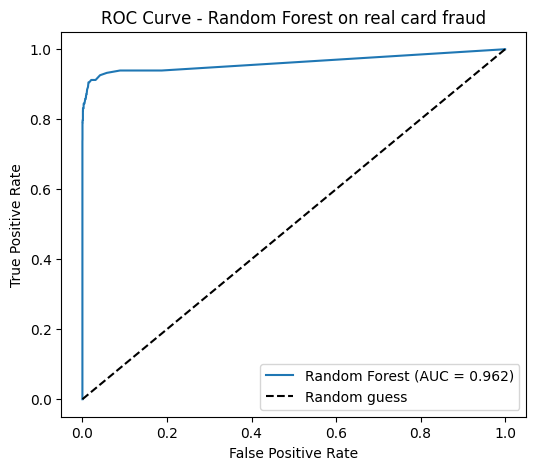

In [4]:
# ROC Curve for Random Forest
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = auc(fpr, tpr)
print("=" * 60)
print("ROC Curve Analysis:")
print("=" * 60)
print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"True Positive Rate at FPR=0.2: {np.interp(0.2, fpr, tpr):.4f}")

# Confusion matrix interpretation
cm = confusion_matrix(y_test, rf_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f}")


# Plot the ROC curve (TPR vs FPR)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest on real card fraud")
plt.legend()
plt.show()

## Summary

### Key Concepts:
1. **Random Forest**: Ensemble of decision trees, reduces overfitting
2. **Naive Bayes**: Probabilistic classifier, excellent for text classification
3. **Confusion Matrix**: Shows TP, TN, FP, FN for detailed evaluation
4. **ROC Curve**: Plots TPR vs FPR, AUC score summarizes performance

### Applications:
- Random Forest: general tabular classification — here, real card-fraud detection
- Naive Bayes: spam detection, text classification, document categorization — here, routing real 911 call descriptions

### What the real data added:
- **Accuracy lied.** Flagging nothing as fraud already scores ~0.976 on the test split; only precision, recall and AUC show whether the model is doing anything.
- **Text is messy.** Dispatchers write in abbreviations and slashes, and the vocabulary is tiny compared with prose — Naive Bayes copes because word counts are all it ever needed.

**Reference:** Course 04, Unit 3: "Applying random forest classifiers" and "Implementing Naive Bayes for text classification"


## 📚 References

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
2. Domingos, P., & Pazzani, M. (1997). *On the Optimality of the Simple Bayesian Classifier under Zero-One Loss*. Machine Learning, 29, 103–130.
3. Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why Do Tree-Based Models Still Outperform Deep Learning on Tabular Data?* NeurIPS 2022 Datasets and Benchmarks. <https://arxiv.org/abs/2207.08815>
